In [2]:
# ライブラリーのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# データの読み込み
data_trained = pd.read_csv('/kaggle/input/titanic/train.csv')
data_test = pd.read_csv('/kaggle/input/titanic/test.csv')
data_gender_submission = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

## 特徴量エンジニアリング
文字列を数値に置き換え
欠損値の扱い

In [4]:
# 教師データとテストデータ双方にエンジニアリングを行うため、結合
data_all = pd.concat([data_trained, data_test], sort = False) # 列の順番は変えずにただ結合してください

### 指針
1. 女性の方が生存率が高い → 男性と女性で特徴量を分けてみる
2. ParchとSibSpはどちらも家族構成の特徴量、また人数に応じて生存率が変わるので、合わせた特徴量を作ってみる
3. Ageは範囲が広いし、Missingも多い。平均で補完が不正確か。→ 中央値、あるいは平均±標準偏差の中からのランダム値で


In [5]:
# 各特徴量の欠損値の数を確認
# データの欠損は　isnull
# TestデータはSurvivedがないので欠損値扱い

data_all.isnull().sum()

# Null418件がテストデータの数を意味する

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [6]:
# Sexの値を男性と女性で分ける
# 同じ特徴量で傾向が大きく違うのであれば、特徴量を分けることで正確に反映し精度が上がるという考え方
# 列を追加
data_all['Sex_male'] = data_all['Sex'].replace(['female', 'male'], [0, 1])
data_all['Sex_female'] = data_all['Sex'].replace(['female', 'male'], [1, 0])
data_all['Sex'] = data_all['Sex'].replace(['female', 'male'], [1, 0])# 既存についても変換
data_all.head()

/tmp/ipykernel_55/1147175446.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Sex_male'] = data_all['Sex'].replace(['female', 'male'], [0, 1])
/tmp/ipykernel_55/1147175446.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Sex_female'] = data_all['Sex'].replace(['female', 'male'], [1, 0])
/tmp/ipykernel_55/1147175446.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,0,1
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,0,1
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1,0


<Axes: xlabel='Families', ylabel='count'>

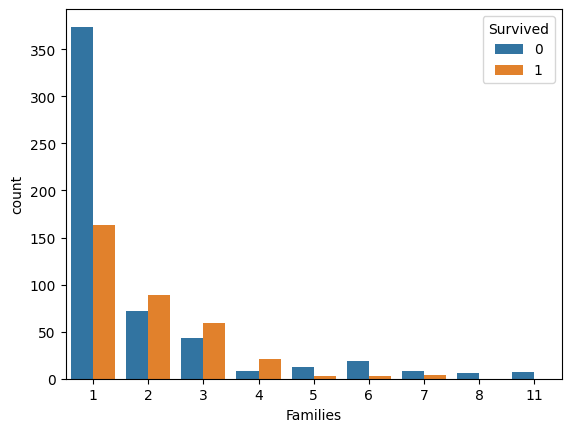

In [7]:
# ParchとSibSpはどちらも家族構成の特徴量、また人数に応じて生存率が変わるので、合わせた特徴量Familiesを作ってみる
data_all['Families'] = data_all['Parch'] + data_all['SibSp'] + 1
# 教師データの傾向を見るため、一時的にテストデータと分離
data_trained['Families'] = data_all['Families'][:len(data_trained)] # 教師データの件数分まで
data_test['Families'] = data_all['Families'][len(data_trained):] # 教師データの件数分以降

sns.countplot(x = 'Families', data = data_trained, hue = 'Survived')
# 単身者は0になるので、＋1で1人という情報を与える　
# Families で最後に＋1すると、単身者と、配偶者や子供や兄弟が一人いた人とが区別つかなくならない？）いっか、全てに＋1してるから、全体的に右によるだけで武ｂｂぷは変わらない


In [8]:
# 単身者は多すぎるので、別の特徴量として抜き出す
data_all['Alone'] = 0
data_all.loc[data_all['Families'] == 1, 'Alone'] = 1 # loc で行データの書き換え。Familiesが1（独り身）に対して、Aloneに1を入れる。
data_all.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female,Families,Alone
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0,2,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,0,1,2,0
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,0,1,2,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1,0,1,1


In [9]:
# Embarkedの欠損値を補完する、数値に置き換える
    # 2件でも欠損があればアルゴリズムは適応できないから
    # 本来なら欠損値を補完する方法を検討するが、今回は2件だし一番多いSで補完
data_all['Embarked'].fillna('S', inplace = True)
data_all['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2], inplace = True) # 変更後の結果をでーたふれ
data_all.head(900)

# One-Hotエンコーディング
    # Embarkedを1、2、3で置き換えると、その大きさに意味があるものとアルゴリズムに勘違いされてしまう場合がある。ので、データの数分、列数が増えるので、データサイズが大きくなる。
    # カテゴリ指定を予めできるものもあり、数値特有の大きさや順番を考慮しないものもある

/tmp/ipykernel_55/2239516266.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_all['Embarked'].fillna('S', inplace = True)
/tmp/ipykernel_55/2239516266.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2], inplace = True) # 変更後の結果をでーたふれ


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female,Families,Alone
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,1,0,2,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,0,1,2,0
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,0,1,2,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,896,NaN,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,0,0,1,3,0
5,897,NaN,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NaN,0,1,0,1,1
6,898,NaN,3,"Connolly, Miss. Kate",1,30.0,0,0,330972,7.6292,NaN,2,0,1,1,1
7,899,NaN,2,"Caldwell, Mr. Albert Francis",0,26.0,1,1,248738,29.0000,NaN,0,1,0,3,0


In [11]:
# Fareは平均で補完。
# Ageは、平均±標準偏差の中からのランダム値で補完
data_all['Fare'].fillna(np.mean(data_all['Fare']), inplace = True)

ave = data_all['Age'].mean()
std = data_all['Age'].std()
data_all['Age'].fillna(np.random.randint(ave - std, ave + std), inplace = True)
# 乱数なので再現性はないし、年齢および欠損値が正規分布に従っていると仮定しているが、中央値も手
# data_all['Age'].fillna(data_all['Age'].median(), inplace = True)
    
data_all.head()

/tmp/ipykernel_55/4048252845.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_all['Fare'].fillna(np.mean(data_all['Fare']), inplace = True)
/tmp/ipykernel_55/4048252845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female,Families,Alone
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,1,0,2,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,0,1,2,0
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,0,1,2,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,1,0,1,1


In [12]:
# 影響のないあるいは少なそうな特徴量については一旦削除。
# drop 行または列で削除する関数。axis - 1で列方向
drop_colums = ['PassengerId', 'Name', 'Ticket', 'Cabin']
data_all.drop(drop_colums, axis = 1, inplace = True)
data_all.isnull().sum()
# まあこれでひとまず欠損値はなくなった
# SibSpやらParchは消していいのか？

Survived      418
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
Sex_male        0
Sex_female      0
Families        0
Alone           0
dtype: int64

In [24]:
# LightGBMはカテゴリ変数を数値に変換しなくても処理してくれる。
categorical_features = ['Sex', 'Embarked', 'Pclass']

In [25]:
# 結合したデータを、再度、教師データと、テストデータに分ける
# len関数は、行数を返してくれる。スライスで該当行を抜き出し。
# 先頭行から教師データの件数だけ抜き出すのと、その一個下のデータから
data_trained = data_all[:len(data_trained)]
data_test = data_all[len(data_trained):]

## モデル作成

### 検証
テストデータでの予測の前に、検証用データ（教示用のデータから作成）でモデルの精度を確かめとくこと。
過学習を防ぐ、またSubmitの回数制限があるので。

LightLgmは、勾配ブースティング手法で決定木を順々に作成しながら学習する

In [27]:
# アルゴリズムに投入。多くの場合別々に投入するのでそのために特徴量と目的変数を分離、x,yと頭文字をつけておく
y_data_trained = data_trained['Survived']
x_data_trained = data_trained.drop('Survived', axis = 1) # 説明変数を格納、dropで目的変数は削除。axis = 1は列を削除の意味
x_data_test = data_test.drop('Survived', axis = 1) # testデータにはSurvivedがなかったが、結合で列が発生したので消しておく。

In [16]:
# 用意。学習用データと検証用データに分割する
# from sklearn.model_selection import train_test_split


# train_test_split関数で、説明・目的変数それぞれに学習用と検証用のデータ、4つを作る↓。
# test_sizeは検証用データの割合、学習用と検証用のデータを7:3で分ける。
# 乱数のシード。モデル改善なので、乱数を発生させるブレが出ないように
# stratify 学習用と検証用のデータで割合を保つ(Survivedの2値が、学習用とテスト用に偏って配置されると検証がうまくいかないので)


# x_data_trained, x_data_valid, y_data_trained, y_data_valid = train_test_split(x_data_trained, y_data_trained, test_size=0.3, random_state=0, stratify=y_data_trained)

### 交差検証
してた検証→ホールドアウト検証

デメリット
・データの偏り（stratifyでSurvivedを分けてはいるがそのほかの特徴量が偏っているかも）
・検証用データは検証のみに使われモデルの学習には使えない

交差検証（Cross Validation）
指定した回数分だけデータセットを分割して、それぞれでホールドアウト検証を実施する。異なる部分から学習用と検証用のデータセットをいくつも作る。

In [29]:
# cross validationでモデル作成
from sklearn.model_selection import KFold # データの複数回分割を楽に実装

# LightGBMをインポート
import lightgbm as lgb

y_data_preds = [] # 各分割でのテストデータ、に対する予測値を格納するリスト
models = [] # 各分割で学習したモデルを格納ｓるリスト
oof_data_train = np.zeros((len(x_data_trained),)) # 各分割での検証用データ、に対する予測値を格納するリスト
# zeros 引数に与えた分だけ0を返す。ここではlenで教師データの件数の数ぶん0が入ったリストになる
cv = KFold(n_splits=5, shuffle=True, random_state=0) # データをどのように分割するか指定
# n_splits 分割数の指定、教師用データを、学習用と検証用に分割したペアを５つ用意する
# shuffle=True,分割前に一度データをシャッフルするという意味　Falseでは元の順番で分割される　（データ偏り軽減のためTrue）
# random_state　乱数のシード固定


# モデル作成におけるベースの情報を目的関数として指定。回帰、分類、精度の指標は何かなど。Objectiveだけ指定しとけば、lgbで勝手にやってくれる。ニ値分類なのでBinary（二項分布の頭文字）
# ハイパーパラメーターを直接指定（公式推奨https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html）
# 過学習になったり、処理時間が長くなったりするので、優先的にいじる必要はない
params = {
    'objective': 'binary',
    'max_bin': 300, # デフォ255を大きめに。各特徴量の最大の分割数。LightGBMはヒストグラムを裏で作っている。アルゴリズムの動作の幅を広められる
    'learning_rate': 0.05, # デフォ0.1を小さめに
    'num_leaves': 40, # デフォ31を大きめに。一つの決定木における末端の最大数。同じくアルゴリズムの表現の幅を広げられる。
    'verbose': -1   # -1: 全て非表示, 0: 最小限, 1: 詳細
}

callbacks = [lgb.early_stopping(stopping_rounds=10)]

#y_data_trainをもとに分割するため、splitの引数にy_data_trainを追加
for fold_id, (train_index, valid_index) in enumerate(cv.split(x_data_trained, y_data_trained)): # splitで教師データを分割、学習用、検証用のペアでIndex番号（行）と返される。
    # enumerate 各分割データペアに固有番号を割り振る
    x_tr = x_data_trained.loc[train_index, :] # loc 指定した（行,列）のデータを取得、Survived一つなので列は指定不要。説明変数の学習用データ
    x_val = x_data_trained.loc[valid_index, :] # 説明変数の検証用データ
    y_tr = y_data_trained[train_index] # 目的変数の学習用データ
    y_val = y_data_trained[valid_index] # 目的変数の検証用データ
# これらがペア5つ用意される
    print(sum(y_tr)/len(y_tr))
    print(sum(y_val)/len(y_val))

# lgbのDataset関数で指定
# 上で指定したカテゴリリストを、ここで指定、いいように扱ってくれる
    lgb_data_train = lgb.Dataset(x_tr, y_tr, categorical_feature = categorical_features)
# 検証用データのreferenceに学習用データを指定
    lgb_data_eval = lgb.Dataset(x_val, y_val, reference = lgb_data_train, categorical_feature = categorical_features)



# train関数。学習用、検証用の順で引数に指定。下の3つはハイパーパラメータ（これ以上に色々ある）。学習の行い方を細かく、慎重に設定できる。
    model = lgb.train(params, lgb_data_train, valid_sets = lgb_data_eval,
                            # verbose_eval = 10,  学習の10回ごとに画面表示する(lgbのバージョンでエラーになるわ)
                            num_boost_round = 1000, # 学習を何回繰り返すか？LightLgmは、勾配ブースティング手法で決定木を順々に作成しながら学習する、これを1000回
                            callbacks=callbacks
                  # early_stopping_rounds = 10) (使えない。)# 大事。精度が上がりやすいが過学習が起こりやすいので、roundの処理を止めてあげる。誤差がこれ以上小さくならない、タイミングで、10回だけは様子見で学習してから、　変わらないならストップする
                 )
# Training until validation scores don't improve for 10 rounds → 検証用データを使って行なった予測結果のスコアが、10回の学習までに改善されなねければ、学習を続ける、の意味。誤差が変わらないとこまで学習を続けてくれる
# binary_logloss は小さいほど予測結果に近い。学習用データでモデルを作成し、精度を検証用データで検証しながら学習進めていき、予測値が検証用データの持つ正解に近いモデルだったが、それ以降は10回ずれ出した

# • LightGBM は 1000回学習する予定だった
# • でも 25回目で最良スコアが出た
# • そこから 10回改善しなかった
# • → 過学習を防ぐために自動で学習を止めた
# これは early stopping が正しく働いた理想的な動作。

# 作成されてモデルで予測を行う処理
    oof_data_train[valid_index] = model.predict(x_val, num_iteration=model.best_iteration)
    # 上で用意した、教師データの件数分0が入ったリストに予測値を格納。Predictに検証用データを指定して予測を行い、検証用データごとに対応したIndex番号の位置に結果を入れる
    # 検証用データは、教師用データからIndex番号を指定して、一部抜き出して作成してた→抜き出したIndex番号に該当する部分に予測結果を格納する
    y_data_pred = model.predict(x_data_test, num_iteration=model.best_iteration) # テストデータに対する予測
    y_data_preds.append(y_data_pred) # 5回個々に作成された予測をAppendで追加
    models.append(model)

0.38342696629213485
0.3854748603351955
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[69]	valid_0's binary_logloss: 0.375912
0.38429172510518933
0.38202247191011235
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[49]	valid_0's binary_logloss: 0.37955
0.38429172510518933
0.38202247191011235
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[61]	valid_0's binary_logloss: 0.413063
0.38429172510518933
0.38202247191011235
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[33]	valid_0's binary_logloss: 0.447927
0.38288920056100983
0.38764044943820225
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[39]	valid_0's binary_logloss: 0.474626


In [30]:
# 各モデルのスコアと平均を計算
scores = [
    m.best_score['valid_0']['binary_logloss'] for m in models # 繰り返しの処理部分　For条件の順に書く
    # models 5回分そものの　。mに入れて、best_scoreで精度の高いものを取り出せる。実行結果に表示のキーワードを指定
]
score = sum(scores) / len(scores)
print(scores)
print(score)

[np.float64(0.3759117707770837), np.float64(0.3795496923814405), np.float64(0.4130632476449113), np.float64(0.44792730634913036), np.float64(0.4746259012898957)]
0.4182155836884923


In [31]:
# oof_data_trainに対する正解率を計算
from sklearn.metrics import accuracy_score

y_data_pred_oof = (oof_data_train > 0.5).astype(int) # oof_data_train 検証の予測値
accuracy_score(y_data_trained, y_data_pred_oof)

# 検証による予測結果が83％正解している意味、改善するか、このモデルを使うか

0.8316498316498316

## 予測

In [32]:
# 5回分の予測結果を平均
y_pred_submit = sum(y_data_preds) / len(y_data_preds)
y_pred_submit = (y_pred_submit > 0.5).astype(int)
y_pred_submit

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [45]:
# y_data_pred = model.predict(x_data_test, num_iteration = model.best_iteration)

# num_iteration 最適な回数で予測してください（25回だった）
# y_data_pred[:5]

array([0.04162828, 0.51215607, 0.11467115, 0.0535265 , 0.39819364])

In [46]:
# 0.5を上回れば1と予測したとみなす
# y_data_pred = (y_data_pred > 0.5).astype(int) # astypeで小数型から整数型
# y_data_pred[:5]

array([0, 1, 0, 0, 0])

## Submit

In [33]:
# 予測結果をSubmit用のCSVファイルとして作成
submit = data_gender_submission # 冒頭で作った変数。提出用CSVのこと。めんどいのでsubmitとする。
submit['Survived'] = list(map(int, y_pred_submit)) 
# map 指定した要素に対して、適用したい関数（int）を適用できる関数。予測結果を整数型にして提出フォーマットに合わせるため。
# リストで提出用ファイルに.
submit.to_csv('Kfold_submit.csv', index = False) # 出力ファイル名,index番号は出力しない


# データ量が多くないので、パラメータいじって丁寧にしすぎて過学習気味になっているか？
# 特徴量エンジニアリングん方が遥かに重要！！